# Set-up

In [1]:
# Importing libraries
import os
import glob
import json
import random

import numpy as np
import pandas as pd
import pyBigWig

import matplotlib.pyplot as plt
import seaborn as sns

def plot_tracks(tracks, interval, height=1.5, colors=None, sharey=False):
  _, axes = plt.subplots(len(tracks), 1, figsize=(20, height * len(tracks)), sharex=True, sharey=sharey)
  if not isinstance(axes, np.ndarray):
    axes = [axes]
  for ax, (title, y) in zip(axes, tracks.items()):
    if colors is not None:
      ax.fill_between(np.linspace(interval["start"], interval["end"], num=len(y)), y, color=colors[title])
    else:
      ax.fill_between(np.linspace(interval["start"], interval["end"], num=len(y)), y)
    ax.set_title(title)
    sns.despine(top=True, right=True, bottom=True)
  ax.set_xlabel(f"{interval['chrom']}:{interval['start']}-{interval['end']}")
  plt.tight_layout()

def plot_tracks_from_locus(locus, bws, colors, sharey=False):
    chrom, coord = locus.split(":")
    start, end = coord.split("-")
    start, end = int(start), int(end)
    interval = {"chrom": chrom, "start": int(start), "end": int(end)}
    tracks = {k: np.nan_to_num(np.array(bw.values(chrom, start, end))) for k, bw in bws.items()}
    plot_tracks(tracks, interval, height=1.5, colors=colors, sharey=sharey)

The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


In [2]:
import pandas as pd

# Load colors from config
cell_type_meta = pd.read_csv(
    "/cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/config/cell_type_metadata.tsv",
    sep="\t"
)
color_dict = dict(zip(cell_type_meta["cell_type"], cell_type_meta["color"]))
color_dict


{'DE': '#f4a582',
 'PGT1': '#d6604d',
 'PGT2': '#b2182b',
 'PGT3': '#67001f',
 'PFG1': '#fdae61',
 'PFG2': '#f46d43',
 'PP1': '#fee08b',
 'PP2': '#d4b13f',
 'ENP_phase1': '#66c2a5',
 'early_ENP': '#3288bd',
 'late_ENP': '#1a5276',
 'early_SC_beta': '#5e4fa2',
 'late_SC_beta': '#3b2d7e',
 'early_SC_alpha': '#e41a1c',
 'late_SC_alpha': '#a50f15',
 'early_SC_EC': '#4daf4a',
 'late_SC_EC': '#276419',
 'SC_delta_GHRL': '#ff7f00',
 'proliferating_endocrine': '#984ea3',
 'exocrine': '#999999',
 'liver': '#a65628',
 'FB_FLT1': '#e7969c'}

In [3]:
# Paths
path_out = "/cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/results/3_single_task_models"

os.makedirs(path_out + "/summary", exist_ok=True)


# Data overview

In [4]:
# Fragment counting skipped — fragments are in legacy layout
# Data overview will be built from model outputs only


In [5]:
# Build data overview from model outputs
import glob

# Get all cell types with models
celltypes = sorted([os.path.basename(d) for d in glob.glob(f"{path_out}/*/fold_0/chrombpnet")])
celltypes = [ct.replace("/fold_0/chrombpnet", "") for ct in celltypes]

# Actually just get dirnames
celltypes = sorted(set(
    os.path.basename(os.path.dirname(os.path.dirname(os.path.dirname(f))))
    for f in glob.glob(f"{path_out}/*/fold_*/chrombpnet/*/evaluation/chrombpnet_metrics.json")
))

df = pd.DataFrame({"Cell Type": celltypes})
df = df.set_index("Cell Type")
df.to_csv(f"{path_out}/summary/data_overview.csv")
print(f"Found {len(celltypes)} cell types with ChromBPNet models")
df


Found 1 cell types with ChromBPNet models


""
Cell Type
chrombpnet


# Bias model overview

In [6]:
# Negatives and bias model params not available in current layout
# Skipping — bias metrics loaded directly below
negatives_df = pd.DataFrame()
bias_data_params = pd.DataFrame()

# Load bias metrics directly
bias_metrics = pd.DataFrame()
for f in glob.glob(f"{path_out}/*/fold_*/chrombpnet/*/evaluation/bias_metrics.json"):
    celltype = f.split("/")[-6]
    fold = f.split("/")[-5]
    beta = f.split("/")[-3]
    with open(f, "r") as fh:
        curr_dict = json.load(fh)
    curr_dict = {f"{k1}_{k2}_{k3}": v3 for k1, v1 in curr_dict.items() for k2, v2 in v1.items() for k3, v3 in v2.items()}
    curr_df = pd.DataFrame(curr_dict, index=[0])
    curr_df["celltype"] = celltype
    curr_df["beta"] = beta
    curr_df["fold"] = fold
    bias_metrics = pd.concat([bias_metrics, curr_df], ignore_index=True)

bias_clean = bias_metrics.copy()
bias_clean = bias_clean.rename(columns={"celltype": "Cell Type"})
bias_clean.to_csv(f"{path_out}/summary/bias_metrics.csv", index=False)
print(f"Found bias metrics for {len(bias_clean)} models")
bias_clean.head()


Found bias metrics for 22 models


,counts_metrics_peaks_spearmanr,counts_metrics_peaks_pearsonr,counts_metrics_peaks_mse,profile_metrics_peaks_median_jsd,profile_metrics_peaks_median_norm_jsd,Cell Type,beta,fold
0,0.009447,-0.031973,9.065786,0.585813,0.198315,late_SC_alpha,0.5,fold_0
1,0.088758,0.023691,9.604087,0.560192,0.223724,early_SC_EC,0.5,fold_0
2,0.099732,0.032295,5.764531,0.622851,0.173951,liver,0.5,fold_0
3,0.052970,-0.007987,8.584097,0.586231,0.201824,PGT2,0.5,fold_0
4,0.017316,-0.050348,4.000819,0.675343,0.132567,ENP_phase1,0.5,fold_0


In [7]:
# Color check skipped


# ChromBPNet model overview

In [8]:
# Same for full model
model_params = pd.DataFrame()
for f in glob.glob(f"{path_out}/*/*/chrombpnet/*/logs/*_model_params.tsv"):
    celltype = f.split("/")[-6]
    fold = f.split("/")[-5]
    beta = f.split("/")[-3]
    curr_df = pd.read_csv(f, sep="\t", index_col=0, header=None).T
    curr_df["celltype"] = celltype
    curr_df["beta"] = beta
    curr_df["fold"] = fold
    model_params = pd.concat([model_params, curr_df], ignore_index=True)

# Metrics
model_metrics = pd.DataFrame()
for f in glob.glob(f"{path_out}/*/*/chrombpnet/*/evaluation/chrombpnet_metrics.json"):
    celltype = f.split("/")[-6]
    fold = f.split("/")[-5]
    beta = f.split("/")[-3]
    with open(f, "r") as fh:
        curr_dict = json.load(fh)
    curr_dict = {f"{k1}_{k2}_{k3}": v3 for k1, v1 in curr_dict.items() for k2, v2 in v1.items() for k3, v3 in v2.items()}
    curr_df = pd.DataFrame(curr_dict, index=[0])
    curr_df["celltype"] = celltype
    curr_df["beta"] = beta
    curr_df["fold"] = fold
    model_metrics = pd.concat([model_metrics, curr_df], ignore_index=True)

# merge model_params and model_metrics
model = model_params.merge(model_metrics, on=["celltype", "beta", "fold"])

# Clean up dataframe
model_clean = model[["celltype", "beta", "fold", "counts_metrics_peaks_pearsonr", "profile_metrics_peaks_median_jsd"]]
model_clean.columns = ["Cell Type", "Beta", "Fold", "ChromBPNet Pearson r in Peaks", "ChromBPNet Median JSD in Peaks"]
model_clean["lower_celltype"] = model_clean["Cell Type"].str.lower()
model_clean = model_clean.sort_values(["lower_celltype", "Beta", "Fold"])
model_clean = model_clean.drop(columns="lower_celltype")
model_clean["ChromBPNet Pearson r in Peaks"] = model_clean["ChromBPNet Pearson r in Peaks"].round(3)
model_clean["ChromBPNet Median JSD in Peaks"] = model_clean["ChromBPNet Median JSD in Peaks"].round(3)

# Save
model_clean.to_csv(f"{path_out}/summary/model_metrics.csv", index=False)

# Check it
model_clean.head()

/tmp/ipykernel_1101728/1327857339.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_clean["lower_celltype"] = model_clean["Cell Type"].str.lower()


,Cell Type,Beta,Fold,ChromBPNet Pearson r in Peaks,ChromBPNet Median JSD in Peaks
11,DE,0.5,fold_0,0.851,0.490
7,early_ENP,0.5,fold_0,0.835,0.500
18,early_SC_alpha,0.5,fold_0,0.822,0.554
20,early_SC_beta,0.5,fold_0,0.810,0.471
1,early_SC_EC,0.5,fold_0,0.818,0.501


In [9]:
# Color check skipped


# Plot

In [10]:
# Merge model metrics with data overview
model_clean = model_metrics.copy()
model_clean = model_clean.rename(columns={"celltype": "Cell Type"})
model_clean.to_csv(f"{path_out}/summary/model_metrics.csv", index=False)
print(f"Found ChromBPNet metrics for {len(model_clean)} models")
model_clean.head()


Found ChromBPNet metrics for 22 models


,counts_metrics_peaks_spearmanr,counts_metrics_peaks_pearsonr,counts_metrics_peaks_mse,profile_metrics_peaks_median_jsd,profile_metrics_peaks_median_norm_jsd,Cell Type,beta,fold
0,0.731553,0.813103,0.525802,0.520214,0.284458,late_SC_alpha,0.5,fold_0
1,0.715881,0.818236,0.440140,0.500837,0.304603,early_SC_EC,0.5,fold_0
2,0.735477,0.826539,0.343929,0.574692,0.236761,liver,0.5,fold_0
3,0.751003,0.836999,0.545062,0.521897,0.286562,PGT2,0.5,fold_0
4,0.791837,0.864906,0.320335,0.632465,0.184982,ENP_phase1,0.5,fold_0


Count Pearson cols: ['counts_metrics_peaks_pearsonr']
Profile JSD cols: ['profile_metrics_peaks_median_jsd', 'profile_metrics_peaks_median_norm_jsd']


/tmp/ipykernel_1101728/2709674174.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=count_col, y="Cell Type", data=plot_df, ax=axs[0], orient="h", palette=color_dict)


/tmp/ipykernel_1101728/2709674174.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=profile_col, y="Cell Type", data=plot_df, ax=axs[1], orient="h", palette=color_dict)


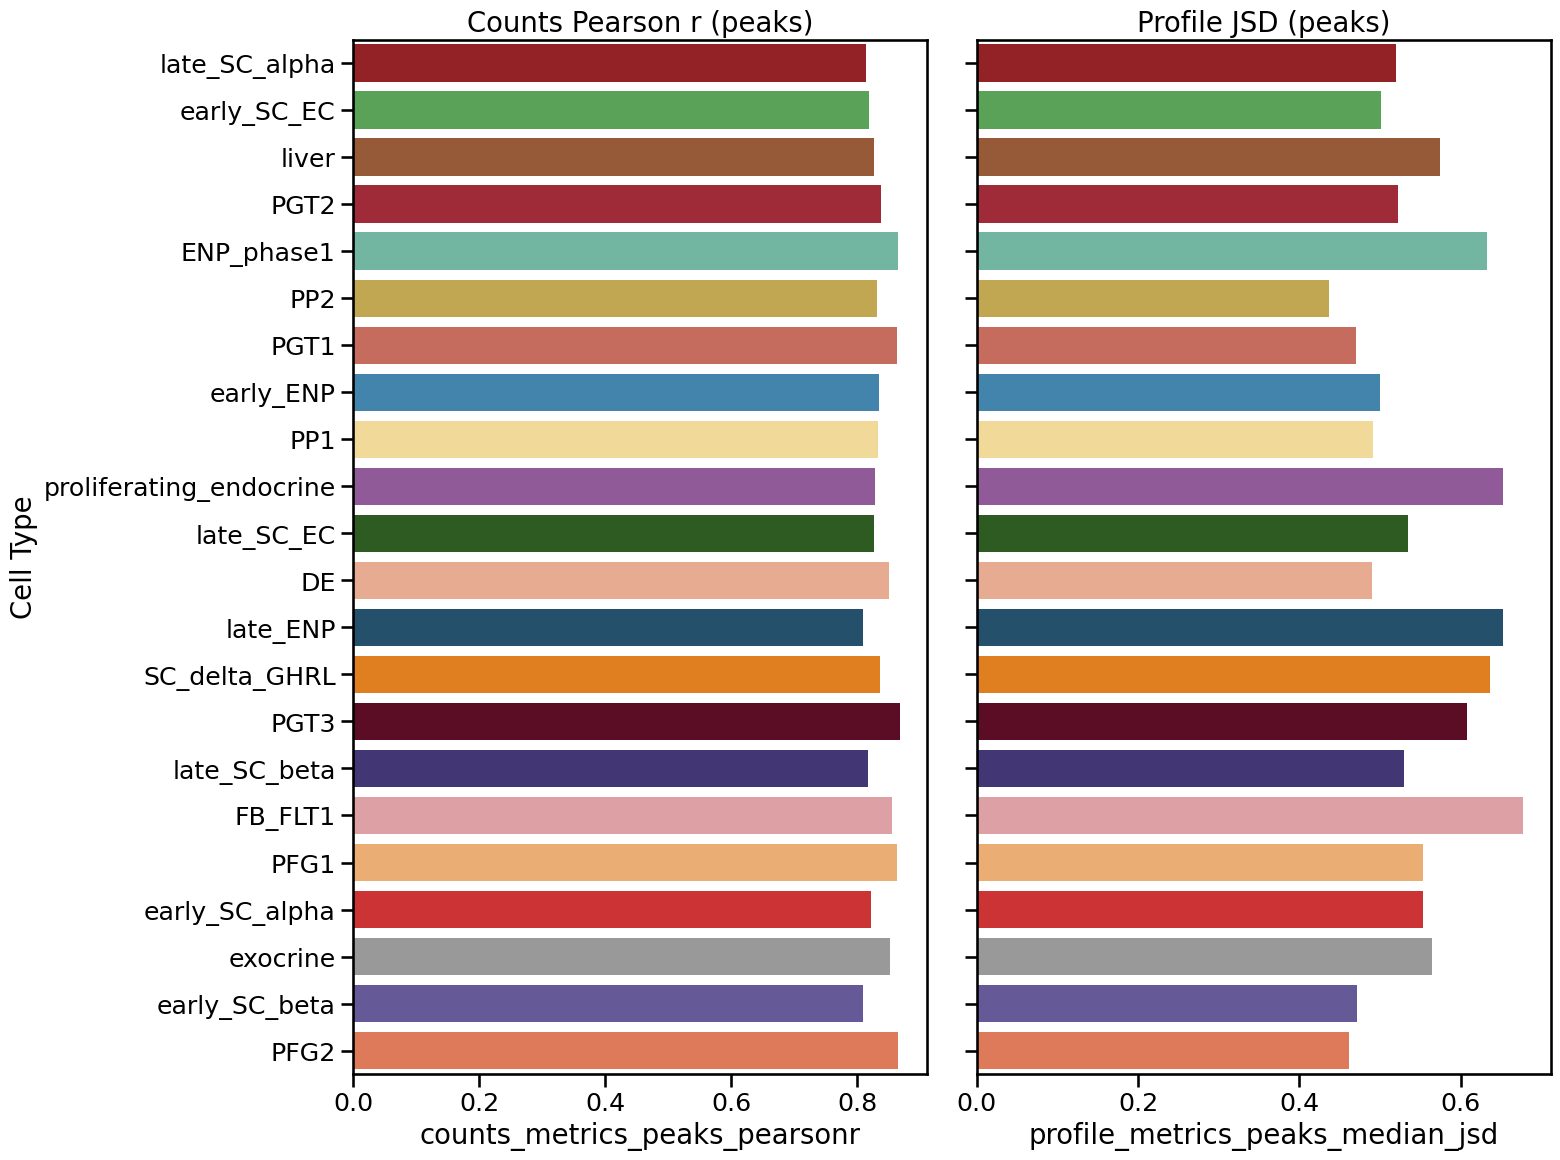

In [11]:
# Plot key ChromBPNet metrics
plot_df = model_clean.copy()

# Get the key metric columns
count_cols = [c for c in plot_df.columns if "counts" in c.lower() and "pearson" in c.lower()]
profile_cols = [c for c in plot_df.columns if "profile" in c.lower() and "jsd" in c.lower()]
print("Count Pearson cols:", count_cols)
print("Profile JSD cols:", profile_cols)

# Use the peaks metrics if available
count_col = [c for c in count_cols if "peaks" in c.lower() and "all" not in c.lower()]
profile_col = [c for c in profile_cols if "peaks" in c.lower() and "all" not in c.lower()]

if count_col and profile_col:
    count_col = count_col[0]
    profile_col = profile_col[0]
    
    with sns.plotting_context("talk", font_scale=1.1):
        fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(16, 12), sharey=True)
        
        sns.barplot(x=count_col, y="Cell Type", data=plot_df, ax=axs[0], orient="h", palette=color_dict)
        axs[0].set_title("Counts Pearson r (peaks)")
        
        sns.barplot(x=profile_col, y="Cell Type", data=plot_df, ax=axs[1], orient="h", palette=color_dict)
        axs[1].set_title("Profile JSD (peaks)")
        
        plt.tight_layout()
        plt.savefig(f"{path_out}/summary/chrombpnet_metrics.pdf", dpi=300, bbox_inches="tight")
        plt.show()
else:
    print("Available columns:", plot_df.columns.tolist())


In [12]:
# Bias/negatives plot skipped — data not available in current layout


# Predictions

In [13]:
# Get all the /cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/models/D4_DE_CDH8+/fold_0/chrombpnet/0.5/predictions/D4_DE_CDH8+_chrombpnet_nobias.bw from path out
bw_files = {}
for f in glob.glob(f"{path_out}/*/fold_*/chrombpnet/*/predictions/*_nobias.bw"):
    celltype = os.path.basename(f).split("_chrombpnet_nobias.bw")[0]
    bw = pyBigWig.open(f)
    bw_files[celltype] = bw
len(bw_files)

22

In [14]:
# Color check skipped


# Contributions

In [15]:
# Get all the /cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/models/D15_liver/fold_0/chrombpnet/0.5/contributions/D15_liver.counts_scores.bw
bw_files = {}
for f in glob.glob(f"{path_out}/*/fold_*/chrombpnet/*/contributions/*.counts_scores.bw"):
    celltype = os.path.basename(f).split(".counts_scores.bw")[0]
    bw = pyBigWig.open(f)
    bw_files[celltype] = bw
len(bw_files)

22

In [16]:
# Get all the /cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/models/D15_liver/fold_0/chrombpnet/0.5/contributions/D15_liver.counts_scores.bw
bw_files = {}
for f in glob.glob(f"{path_out}/*/fold_*/chrombpnet/*/contributions/*.profile_scores.bw"):
    celltype = os.path.basename(f).split(".profile_scores.bw")[0]
    bw = pyBigWig.open(f)
    bw_files[celltype] = bw
len(bw_files)

22

In [17]:
bw_files

{'late_SC_alpha': <pyBigWig.bigWigFile at 0x155517762220>,
 'early_SC_EC': <pyBigWig.bigWigFile at 0x155517763d20>,
 'liver': <pyBigWig.bigWigFile at 0x1555177627c0>,
 'PGT2': <pyBigWig.bigWigFile at 0x155517763630>,
 'ENP_phase1': <pyBigWig.bigWigFile at 0x155517763d50>,
 'PP2': <pyBigWig.bigWigFile at 0x155517763ba0>,
 'PGT1': <pyBigWig.bigWigFile at 0x155517763300>,
 'early_ENP': <pyBigWig.bigWigFile at 0x155517763390>,
 'PP1': <pyBigWig.bigWigFile at 0x155517763c60>,
 'proliferating_endocrine': <pyBigWig.bigWigFile at 0x1555177638d0>,
 'late_SC_EC': <pyBigWig.bigWigFile at 0x155517763450>,
 'DE': <pyBigWig.bigWigFile at 0x155517763930>,
 'late_ENP': <pyBigWig.bigWigFile at 0x1555177639c0>,
 'SC_delta_GHRL': <pyBigWig.bigWigFile at 0x155517763c00>,
 'PGT3': <pyBigWig.bigWigFile at 0x1555177625e0>,
 'late_SC_beta': <pyBigWig.bigWigFile at 0x1555177633c0>,
 'FB_FLT1': <pyBigWig.bigWigFile at 0x155517763510>,
 'PFG1': <pyBigWig.bigWigFile at 0x155517763750>,
 'early_SC_alpha': <pyBigWi

In [18]:
# Color check skipped


# DONE

---